# Prognostic Value of Frailty in Heart Failure Patients

### Set up

In [130]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import re
import pyreadstat
import scipy.stats as stats
from scipy.stats import chi2
from lifelines import KaplanMeierFitter, CoxPHFitter
from lifelines.statistics import logrank_test, proportional_hazard_test, TimeTransformers
from lifelines.utils import k_fold_cross_validation, concordance_index
import matplotlib.gridspec as gridspec


# Set plotting style
sns.set_theme(style="whitegrid")
plt.rcParams['figure.figsize'] = (10, 6)
plt.rcParams['font.size'] = 11


## 1. Data Loading & Cleaning & Exploration

In [131]:
df, meta = pyreadstat.read_sav('Fried_Frailty_HF_313pts.sav')
df_origin = df.copy()
df.head()

,age,agegroup,gender,livingalone,maritalstatus,residence,education,income,smoking,BMIgroup,...,RAASi,BB,MRA,SGLT2i,Furosemide,Digoxin,Event_HF_Hospitalization,Time_HF_hospitalization,Event_All_Hospitalization,Time_All_hospitalization
0,93.0,1.0,0.0,0.0,0.0,0.0,1.0,1.0,0.0,2.0,...,2.0,0.0,0.0,1.0,0.0,0.0,0.0,190.0,1.0,16.0
1,91.0,1.0,0.0,0.0,0.0,0.0,1.0,1.0,0.0,2.0,...,2.0,0.0,0.0,0.0,0.0,0.0,1.0,39.0,1.0,39.0
2,83.0,1.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,2.0,...,2.0,0.0,0.0,0.0,0.0,0.0,1.0,46.0,1.0,46.0
3,83.0,1.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,3.0,...,2.0,1.0,0.0,0.0,0.0,0.0,0.0,190.0,1.0,11.0
4,85.0,1.0,0.0,0.0,1.0,0.0,0.0,1.0,0.0,0.0,...,2.0,0.0,0.0,1.0,0.0,0.0,0.0,190.0,1.0,28.0


In [132]:
df.shape

(313, 41)

In [133]:
df.isna().sum().sum()

np.int64(0)

In [134]:
df.columns

Index(['age', 'agegroup', 'gender', 'livingalone', 'maritalstatus',
       'residence', 'education', 'income', 'smoking', 'BMIgroup',
       'hypertension', 'dyslipidemia', 'diabetes', 'historyMI', 'CCS',
       'historystroke', 'AF', 'CKD', 'Anemia', 'COPD', 'Fried_frailty_2',
       'Limitation_ADL', 'Limitation_IADL', 'Malnutrition', 'Depression',
       'Polypharmacy', 'HF_phenotype', 'NYHA', 'Dilated_LV', 'Concentric_LV',
       'Dilated_LA', 'RAASi', 'BB', 'MRA', 'SGLT2i', 'Furosemide', 'Digoxin',
       'Event_HF_Hospitalization', 'Time_HF_hospitalization',
       'Event_All_Hospitalization', 'Time_All_hospitalization'],
      dtype='object')

In [135]:
print(pd.crosstab(df['CKD'], df['Event_All_Hospitalization']))

Event_All_Hospitalization  0.0  1.0
CKD                                
0.0                        131   46
1.0                         64   72


In [136]:
for key, values in meta.variable_value_labels.items():
    print(key, values)

agegroup {0.0: '<75', 1.0: '>=75'}
gender {0.0: 'male', 1.0: 'female'}
livingalone {0.0: 'no', 1.0: 'yes'}
maritalstatus {0.0: 'married', 1.0: 'single\u200e/widowed\u200e/divorced'}
residence {0.0: 'urban', 1.0: 'rural'}
education {0.0: '<=12', 1.0: 'Tertiary'}
income {0.0: 'independent', 1.0: 'dependent'}
smoking {0.0: 'no', 1.0: 'yes'}
BMIgroup {0.0: 'normal', 1.0: 'underweight', 2.0: 'overweight', 3.0: 'obesity'}
hypertension {0.0: 'no', 1.0: 'yes'}
dyslipidemia {0.0: 'no', 1.0: 'yes'}
diabetes {0.0: 'no', 1.0: 'yes'}
historyMI {0.0: 'no', 1.0: 'yes'}
CCS {0.0: 'no', 1.0: 'yes'}
historystroke {0.0: 'no', 1.0: 'yes'}
AF {0.0: 'no', 1.0: 'yes'}
CKD {0.0: 'no', 1.0: 'yes'}
Anemia {0.0: 'no', 1.0: 'yes'}
COPD {0.0: 'no', 1.0: 'yes'}
Fried_frailty_2 {0.0: 'no', 1.0: 'yes'}
Limitation_ADL {0.0: 'no', 1.0: 'yes'}
Limitation_IADL {0.0: 'no', 1.0: 'yes'}
Malnutrition {0.0: 'no', 1.0: 'yes'}
Depression {0.0: 'no', 1.0: 'yes'}
Polypharmacy {0.0: 'no', 1.0: 'yes'}
HF_phenotype {0.0: 'HFmrEF', 1

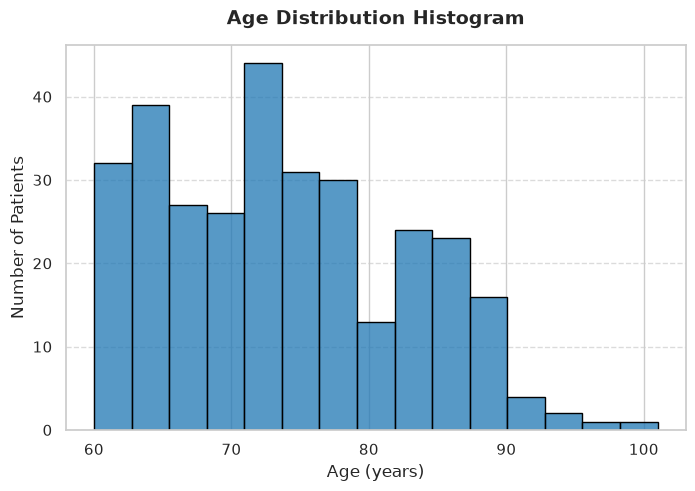

In [137]:
plt.figure(figsize=(8, 5))

sns.histplot(
    data=df, 
    x='age', 
    bins=15,            # Number of bins/intervals
    color='#1f77b4',    # Steel blue color
    edgecolor='black'   # Dark borders between bars
)

plt.title('Age Distribution Histogram', fontsize=14, fontweight='bold', pad=15)
plt.xlabel('Age (years)', fontsize=12)
plt.ylabel('Number of Patients', fontsize=12)
plt.grid(axis='y', linestyle='--', alpha=0.7) 

plt.show()


In [138]:
# If RAASi is 0, set to 0. If it is 1 or 2, set to 1. Otherwise, keep it as NaN.
df["RAASi_B"] = np.where(
    df["RAASi"] == 0, 
    0, 
    np.where(df["RAASi"].isin([1, 2, 1.0, 2.0]), 1, np.nan)
)


In [139]:
df = pd.get_dummies(
    df,
    columns=['BMIgroup'],
    drop_first=True, 
    dtype=int
)

df = pd.concat([df, df_origin[['BMIgroup']]], axis=1)

df.head()

,age,agegroup,gender,livingalone,maritalstatus,residence,education,income,smoking,hypertension,...,Digoxin,Event_HF_Hospitalization,Time_HF_hospitalization,Event_All_Hospitalization,Time_All_hospitalization,RAASi_B,BMIgroup_1.0,BMIgroup_2.0,BMIgroup_3.0,BMIgroup
0,93.0,1.0,0.0,0.0,0.0,0.0,1.0,1.0,0.0,1.0,...,0.0,0.0,190.0,1.0,16.0,1.0,0,1,0,2.0
1,91.0,1.0,0.0,0.0,0.0,0.0,1.0,1.0,0.0,1.0,...,0.0,1.0,39.0,1.0,39.0,1.0,0,1,0,2.0
2,83.0,1.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,1.0,...,0.0,1.0,46.0,1.0,46.0,1.0,0,1,0,2.0
3,83.0,1.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,1.0,...,0.0,0.0,190.0,1.0,11.0,1.0,0,0,1,3.0
4,85.0,1.0,0.0,0.0,1.0,0.0,0.0,1.0,0.0,1.0,...,0.0,0.0,190.0,1.0,28.0,1.0,0,0,0,0.0


In [140]:

event_var = ['Time_All_hospitalization', 'Event_All_Hospitalization', 'Time_HF_hospitalization', 'Event_HF_Hospitalization']

dup_var = ['agegroup', 'BMIgroup'] # Use 'age', 'BMIgroup_1.0', 'BMIgroup_2.0', 'BMIgroup_3.0'


candidate_confounders = [c for c in df.columns if c not in (dup_var + event_var)]


var_label_map = {
    # Primary Target 
    'Fried_frailty_2': 'Fried Frailty',
    
    # Demographics & Lifestyle
    'age': "Age",
    'agegroup': "Age Group",
    'gender': 'Gender',
    'maritalstatus': 'Marital Status',
    'livingalone': 'Living Alone',
    'residence': 'Residence',
    'education': 'Education Level',
    'income': 'Income Level',
    'smoking': 'Smoking History',
    
    # Dummied BMI Group (Reference: Normal [0.0])
    'BMIgroup': 'BMI group',
    'BMIgroup_1.0': 'BMI: Underweight',
    'BMIgroup_2.0': 'BMI: Overweight',
    'BMIgroup_3.0': 'BMI: Obesity',

    # Functional Status & Clinical State
    'NYHA': 'NYHA Class',
    'Limitation_ADL': 'ADL Limitation',
    'Limitation_IADL': 'IADL Limitation',
    'Malnutrition': 'Malnutrition',
    'Depression': 'Depression',
    'Polypharmacy': 'Polypharmacy',
    'Anemia': 'Anemia',
    
    # Comorbidities
    'hypertension': 'Hypertension',
    'dyslipidemia': 'Dyslipidemia',
    'diabetes': 'Diabetes Mellitus',
    'historyMI': 'History of MI',
    'historystroke': 'History of Stroke',
    'AF': 'Atrial Fibrillation',
    'CKD': 'CKD',
    'COPD': 'COPD',
    'CCS': 'CCS',

    # Echocardiographic Parameters
    'HF_phenotype': 'HFpEF',
    'Dilated_LV': 'Dilated LV',
    'Concentric_LV': 'Concentric LV',
    'Dilated_LA': 'Dilated LA',
    
    # Medications & Therapies (Reference for RAASi: None [0.0])
    'RAASi': "RAASi class",
    'RAASi_B': 'RAASi (any)',
    'BB': 'Beta-Blocker',
    'MRA': 'MRAs',
    'SGLT2i': 'SGLT2i',
    'Furosemide': 'Furosemide',
    'Digoxin': 'Digoxin',

    # Target
    'Time_All_hospitalization': 'All-cause rehospitalisation (time)',
    'Event_All_Hospitalization': 'All-cause rehospitalisation (event)',
    'Time_HF_hospitalization': 'HF rehospitalization (time)',
    'Event_HF_Hospitalization': 'HF rehospitalization (event)'
}


for var in candidate_confounders:
    print(var, " -> ", var_label_map[var])
    print()

age  ->  Age

gender  ->  Gender

livingalone  ->  Living Alone

maritalstatus  ->  Marital Status

residence  ->  Residence

education  ->  Education Level

income  ->  Income Level

smoking  ->  Smoking History

hypertension  ->  Hypertension

dyslipidemia  ->  Dyslipidemia

diabetes  ->  Diabetes Mellitus

historyMI  ->  History of MI

CCS  ->  CCS

historystroke  ->  History of Stroke

AF  ->  Atrial Fibrillation

CKD  ->  CKD

Anemia  ->  Anemia

COPD  ->  COPD

Fried_frailty_2  ->  Fried Frailty

Limitation_ADL  ->  ADL Limitation

Limitation_IADL  ->  IADL Limitation

Malnutrition  ->  Malnutrition

Depression  ->  Depression

Polypharmacy  ->  Polypharmacy

HF_phenotype  ->  HFpEF

NYHA  ->  NYHA Class

Dilated_LV  ->  Dilated LV

Concentric_LV  ->  Concentric LV

Dilated_LA  ->  Dilated LA

RAASi  ->  RAASi class

BB  ->  Beta-Blocker

MRA  ->  MRAs

SGLT2i  ->  SGLT2i

Furosemide  ->  Furosemide

Digoxin  ->  Digoxin

RAASi_B  ->  RAASi (any)

BMIgroup_1.0  ->  BMI: Underweig

## 2. Kaplan-Meier Survival Analysis

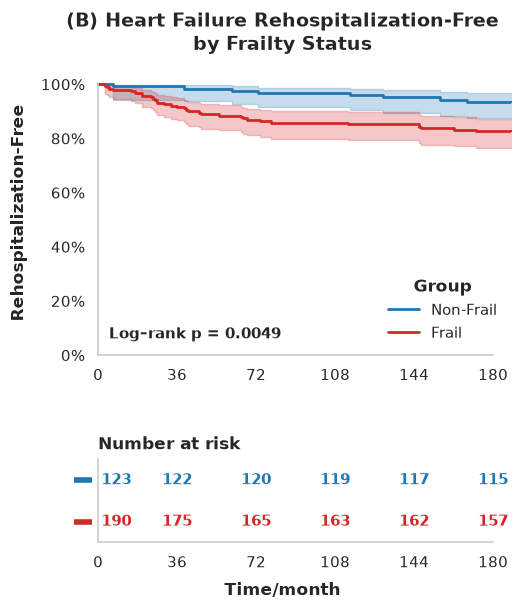

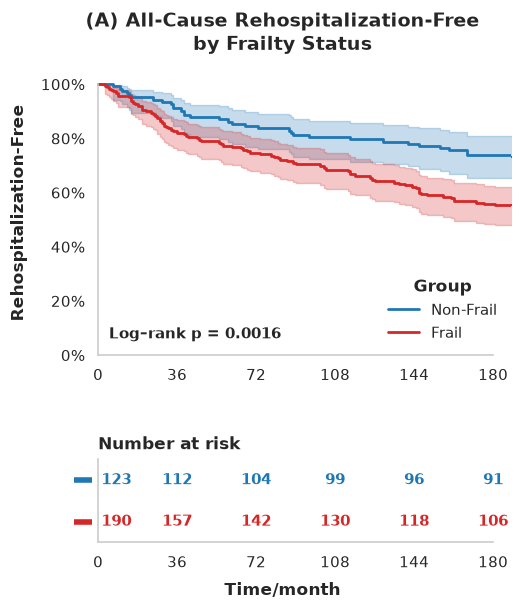

In [141]:
def draw_ggplot_km(df, time_col, event_col, group_col, 
                    title, xlabel, ylabel, ticks, group_labels, 
                    colors, save_path=None):
   
    fig = plt.figure(figsize=(5.5, 6))
    gs = gridspec.GridSpec(2, 1, height_ratios=[4, 1.4], hspace=0.5,
                           left=0.12, right=0.95, top=0.90, bottom=0.10)
    
    ax = fig.add_subplot(gs[0])
    ax_table = fig.add_subplot(gs[1], sharex=ax)
    
    
    def clean_binary(series):
        if pd.api.types.is_numeric_dtype(series) or pd.api.types.is_bool_dtype(series):
            return series.astype(int)
        return series.astype(str).str.strip().str.lower().apply(lambda x: 1 if x in ['yes', '1', '1.0', 'true'] else 0)
        
    df_clean = pd.DataFrame({
        'time': df[time_col].astype(float),
        'event': clean_binary(df[event_col]),
        'group': clean_binary(df[group_col])
    })
    

    g0_mask = (df_clean['group'] == 0)
    g1_mask = (df_clean['group'] == 1)
    

    kmf0 = KaplanMeierFitter()
    kmf1 = KaplanMeierFitter()
    
    kmf0.fit(df_clean.loc[g0_mask, 'time'], df_clean.loc[g0_mask, 'event'], label=group_labels[0])
    kmf1.fit(df_clean.loc[g1_mask, 'time'], df_clean.loc[g1_mask, 'event'], label=group_labels[1])
    

    kmf0.plot_survival_function(ax=ax, color=colors[0], linewidth=2.0, ci_show=True,
                                show_censors=True, censor_styles={'marker': '+', 'ms': 6, 'mew': 1.5})
    kmf1.plot_survival_function(ax=ax, color=colors[1], linewidth=2.0, ci_show=True,
                                show_censors=True, censor_styles={'marker': '+', 'ms': 6, 'mew': 1.5})
    

    max_time = max(ticks)
    ax.set_xlim(-20, max_time + 8)
    ax.set_ylim(0, 1.05)
    

    ax.spines['left'].set_position(('data', 0))
    ax.spines['left'].set_bounds(0, 1.0)
    ax.spines['bottom'].set_position(('data', 0))
    ax.spines['bottom'].set_bounds(0, max_time)
    

    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)
    ax.spines['left'].set_linewidth(1.2)
    ax.spines['bottom'].set_linewidth(1.2)
    
    ax.grid(False)
    

    ax.set_yticks([0, 0.2, 0.4, 0.6, 0.8, 1.0])
    ax.set_yticklabels(['0%', '20%', '40%', '60%', '80%', '100%'], fontsize=11) #, fontweight='bold'
    ax.set_ylabel(ylabel, fontsize=12, fontweight='bold', labelpad=10)
    

    ax.set_xticks(ticks)
    ax.set_xticklabels([str(t) for t in ticks], fontsize=11) # fontweight='bold', 
    ax.set_xlabel('')
    

    lr = logrank_test(
        df_clean.loc[g0_mask, 'time'], df_clean.loc[g1_mask, 'time'],
        df_clean.loc[g0_mask, 'event'], df_clean.loc[g1_mask, 'event']
    )
    p_val = lr.p_value
    p_text = f'Log–rank p = {p_val:.4f}' if p_val >= 0.0001 else 'Log–rank p < 0.0001'
    

    ax.legend(title='Group', title_fontproperties={'weight': 'bold'}, 
              loc='lower right', frameon=False) #, prop={'weight': 'bold'}
              

    ax.text(0.12, 0.1, p_text, transform=ax.transAxes, fontsize=11, fontweight='bold', ha='left', va='top')
    

    m0 = kmf0.median_survival_time_
    m1 = kmf1.median_survival_time_
    
    if np.isfinite(m0):
        ax.plot([0, m0], [0.5, 0.5], color='black', linestyle='--', linewidth=1.2)
        ax.plot([m0, m0], [0, 0.5], color='black', linestyle='--', linewidth=1.2)
    if np.isfinite(m1):
        ax.plot([0, m1], [0.5, 0.5], color='black', linestyle='--', linewidth=1.2)
        ax.plot([m1, m1], [0, 0.5], color='black', linestyle='--', linewidth=1.2)
            
    ax.set_title(title, fontsize=14, fontweight='bold', pad=15)
    

    ax_table.spines['top'].set_visible(False)
    ax_table.spines['right'].set_visible(False)
    

    ax_table.spines['left'].set_position(('data', 0))
    ax_table.spines['left'].set_bounds(0, 2)
    ax_table.spines['bottom'].set_position(('data', 0))
    ax_table.spines['bottom'].set_bounds(0, max_time)
    
    ax_table.spines['left'].set_linewidth(1.2)
    ax_table.spines['bottom'].set_linewidth(1.2)
    ax_table.grid(False)
    

    ax_table.set_xticks(ticks)
    ax_table.set_xticklabels([str(t) for t in ticks],  fontsize=11)
    ax_table.set_xlabel(xlabel, fontsize=12, fontweight='bold', labelpad=8)
    

    ax_table.set_yticks([])
    ax_table.set_yticklabels([])
    

    at_risk_g0 = [sum(df_clean.loc[g0_mask, 'time'] >= t) for t in ticks]
    at_risk_g1 = [sum(df_clean.loc[g1_mask, 'time'] >= t) for t in ticks]
    

    ax_table.hlines(y=1.5, xmin=-11, xmax=-3, color=colors[0], linewidth=4)
    ax_table.hlines(y=0.5, xmin=-11, xmax=-3, color=colors[1], linewidth=4)
    

    for i, t in enumerate(ticks):
        if t == 0:
            x_val = 1.5
            ha_val = 'left'
        else:
            x_val = t
            ha_val = 'center'
            
        ax_table.text(x_val, 1.5, str(at_risk_g0[i]), color=colors[0], 
                      ha=ha_val, va='center', fontweight='bold', fontsize=11)
        ax_table.text(x_val, 0.5, str(at_risk_g1[i]), color=colors[1], 
                      ha=ha_val, va='center', fontweight='bold', fontsize=11)
                      

    ax_table.set_ylim(-0.2, 2.2)
    

    ax_table.text(-15, 1.0, '', rotation='vertical', ha='right', va='center', fontweight='bold', fontsize=12)
    ax_table.text(0, 2.15, 'Number at risk', ha='left', va='bottom', fontweight='bold', fontsize=12)


    if save_path:
        plt.savefig(save_path, dpi=300, bbox_inches='tight')
    plt.show()

ticks = [0, 36, 72, 108, 144, 180]


draw_ggplot_km(
    df=df, 
    time_col='Time_HF_hospitalization', 
    event_col='Event_HF_Hospitalization', 
    group_col='Fried_frailty_2', 
    title='(B) Heart Failure Rehospitalization-Free\nby Frailty Status', 
    xlabel='Time/month', 
    ylabel='Rehospitalization-Free', 
    ticks=ticks, 
    group_labels=['Non-Frail', 'Frail'], 
    colors=['#1f77b4', '#d62728'],
    save_path='Figure 2. Kaplan–Meier curves for rehospitalisation-free survival according to frailty status (B).png'
)


draw_ggplot_km(
    df=df, 
    time_col='Time_All_hospitalization', 
    event_col='Event_All_Hospitalization', 
    group_col='Fried_frailty_2', 
    title='(A) All-Cause Rehospitalization-Free\nby Frailty Status', 
    xlabel='Time/month', 
    ylabel='Rehospitalization-Free', 
    ticks=ticks, 
    group_labels=['Non-Frail', 'Frail'], 
    colors=['#1f77b4', '#d62728'],
    save_path='Figure 2. Kaplan–Meier curves for rehospitalisation-free survival according to frailty status (A).png'
)

## 3. Multivariable Cox Proportional Hazards Models

### 3.1 Variable conditions

In [142]:
df['Event_All_Hospitalization'].value_counts()

Event_All_Hospitalization
0.0    195
1.0    118
Name: count, dtype: int64

In [143]:
# Find variables with value count > 15 in each group

matching_variables = []

for var in candidate_confounders:
    if var in df.columns:
        zeros_count = (df[var] == 0).sum()
        ones_count = (df[var] == 1).sum()
        
        
        if zeros_count > 15 and ones_count > 15:
            matching_variables.append(var)
            print(f"{var:<18} | Count of 0: {zeros_count:<4} | Count of 1: {ones_count:<4}")

print("\nFinal List of Matching Variables:")
print(matching_variables)


gender             | Count of 0: 167  | Count of 1: 146 
maritalstatus      | Count of 0: 199  | Count of 1: 114 
residence          | Count of 0: 234  | Count of 1: 79  
education          | Count of 0: 227  | Count of 1: 86  
income             | Count of 0: 81   | Count of 1: 232 
smoking            | Count of 0: 291  | Count of 1: 22  
hypertension       | Count of 0: 16   | Count of 1: 297 
diabetes           | Count of 0: 189  | Count of 1: 124 
historyMI          | Count of 0: 206  | Count of 1: 107 
CCS                | Count of 0: 111  | Count of 1: 202 
historystroke      | Count of 0: 272  | Count of 1: 41  
AF                 | Count of 0: 227  | Count of 1: 86  
CKD                | Count of 0: 177  | Count of 1: 136 
Anemia             | Count of 0: 291  | Count of 1: 22  
COPD               | Count of 0: 291  | Count of 1: 22  
Fried_frailty_2    | Count of 0: 123  | Count of 1: 190 
Limitation_ADL     | Count of 0: 252  | Count of 1: 61  
Limitation_IADL    | Count of 0

In [144]:
# Find variables with more than 15 events in each group

variables_to_check = matching_variables
event_col = 'Event_All_Hospitalization'

filtered_variables = []

print(f"{'Variable':<22} | Group -> Event Counts")
print("-" * 65)

for var in variables_to_check:
    if var in df.columns:
        
        groups = df[var].dropna().unique()
        
        group_event_counts = {}
        meets_criteria = True
        
        for val in groups:
            
            event_count = ((df[var] == val) & (df[event_col] == 1)).sum()
            group_event_counts[val] = event_count
            
            
            if event_count < 15:
                meets_criteria = False
        
        
        counts_str = ", ".join([f"{g}: {c} events" for g, c in group_event_counts.items()])
        
        if meets_criteria:
            filtered_variables.append(var)
            print(f"{var:<22} | {counts_str} (PASSED)")
        else:
            print(f"{var:<22} | {counts_str} (FAILED - < 10 events)")

print("\n--- Final Filtered Variables List (>= 15 events in all groups) ---")
print(filtered_variables)

Variable               | Group -> Event Counts
-----------------------------------------------------------------
gender                 | 0.0: 64 events, 1.0: 54 events (PASSED)
maritalstatus          | 0.0: 70 events, 1.0: 48 events (PASSED)
residence              | 0.0: 93 events, 1.0: 25 events (PASSED)
education              | 1.0: 32 events, 0.0: 86 events (PASSED)
income                 | 1.0: 91 events, 0.0: 27 events (PASSED)
smoking                | 0.0: 111 events, 1.0: 7 events (FAILED - < 10 events)
hypertension           | 1.0: 112 events, 0.0: 6 events (FAILED - < 10 events)
diabetes               | 1.0: 50 events, 0.0: 68 events (PASSED)
historyMI              | 0.0: 84 events, 1.0: 34 events (PASSED)
CCS                    | 1.0: 68 events, 0.0: 50 events (PASSED)
historystroke          | 0.0: 110 events, 1.0: 8 events (FAILED - < 10 events)
AF                     | 0.0: 77 events, 1.0: 41 events (PASSED)
CKD                    | 1.0: 72 events, 0.0: 46 events (PASSED)


### 3.2 Univariate Cox Model

In [145]:
def univariate_cox_screening(df, time_col, event_col, candidate_variables, 
                             p_threshold=0.2):
    """
    Runs univariate Cox Proportional Hazards regression for each candidate variable.
    Selects variables for the multivariable pool based on p-value threshold or forced status.
    """
    results = []
    
    for var in candidate_variables:
        
        cph = CoxPHFitter()
        try:
            cph.fit(df[[time_col, event_col, var]], duration_col=time_col, event_col=event_col)
            
            summary = cph.summary.loc[var]
            hr = np.exp(summary['coef'])
            ci_lower = np.exp(summary['coef lower 95%'])
            ci_upper = np.exp(summary['coef upper 95%'])
            p_val = summary['p']
            
            results.append({
                'Variable': var,
                'HR (95% CI)': f"{hr:.2f} ({ci_lower:.2f} - {ci_upper:.2f})",
                'coef': summary['coef'],
                'p-value': p_val,
            })
        except Exception as e:
            print(f"Skipping variable '{var}' due to fitting error: {e}")

    df_results = pd.DataFrame(results)
    
    df_results['Selected?'] = (df_results['p-value'] < p_threshold)
    df_results['Selected?'] = df_results['Selected?'].map({True: 'Yes', False: 'No'})
    

    df_results = df_results.sort_values(by='p-value').reset_index(drop=True)
    

    selected_pool = df_results[df_results['Selected?'] == 'Yes']['Variable'].tolist()
    

    print(f"\n=== Univariate Screening Results for {event_col} ===")
    print(df_results[['Variable', 'HR (95% CI)', 'p-value', 'Selected?']].to_string(index=False))
    print(f"\nSelected Multivariable Pool ({len(selected_pool)} variables):")
    print(selected_pool)
    
    return df_results, selected_pool

In [146]:
def draw_forest_plot(df_table, title="Forest Tree Plot", save_path=None):
    
    df = df_table.copy()
    pattern = r"([0-9.]+)\s*\(\s*([0-9.]+)\s*-\s*([0-9.]+)\s*\)"
    parsed = df['HR (95% CI)'].str.extract(pattern).astype(float)
    df['HR'] = parsed[0]
    df['CI_lower'] = parsed[1]
    df['CI_upper'] = parsed[2]
    

    df_plot = df.sort_values(by=['p-value', 'HR'], ascending=[True, False]).reset_index(drop=True)
    

    df_plot = df_plot.iloc[::-1].reset_index(drop=True)
    
    n_rows = len(df_plot)
    if n_rows == 0:
        print("No variables found in the table.")
        return
        

    fig, ax = plt.subplots(figsize=(10.5, 0.45 * n_rows + 2.5), dpi=300)
    fig.patch.set_facecolor('#ffffff')
    ax.set_facecolor('#ffffff')
    
    y_pos = np.arange(n_rows)
    

    left_err = df_plot['HR'] - df_plot['CI_lower']
    right_err = df_plot['CI_upper'] - df_plot['HR']
    

    for i in range(n_rows):
        if i % 2 == 0:
            ax.axhspan(i - 0.3, i + 0.3, color='#f8f9fa', alpha=0.8, zorder=0)
            

    ax.errorbar(df_plot['HR'], y_pos, xerr=[left_err, right_err], fmt='none', 
                ecolor='#455a64', elinewidth=1.8, capsize=4, capthick=1.8, zorder=2)
    

    colors = ['#c62828' if var == 'Fried_frailty_2' else '#1976d2' for var in df_plot['Variable']]
    ax.scatter(df_plot['HR'], y_pos, color=colors, s=60, edgecolors='black', linewidths=0.8, zorder=3)
    

    ax.axvline(x=1.0, color='#78909c', linestyle='--', linewidth=1.2, zorder=1)
    

    ax.set_xscale('log')
    

    min_val = min(df_plot['CI_lower'].min(), 0.1)
    max_val = max(df_plot['CI_upper'].max(), 20)
    ticks = [0.1, 0.2, 0.5, 1, 2, 5, 10]
    ticks = [t for t in ticks if t >= min_val * 0.8 and t <= max_val * 1.2]
    if 1.0 not in ticks:
        ticks.append(1.0)
    ticks = sorted(ticks)
    
    ax.set_xticks(ticks)
    ax.get_xaxis().set_major_formatter(plt.ScalarFormatter())
    ax.set_xticklabels([str(t) for t in ticks], fontsize=10)
    
    # Set axis limits (raised upper limit to make room for headers)
    ax.set_ylim(-0.5, n_rows + 1.0)
    ax.set_yticks(y_pos)
    ax.set_yticklabels([]) 
    

    ax.grid(False)
    
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)
    ax.spines['left'].set_color('#cfd8dc')
    ax.spines['bottom'].set_color('#cfd8dc')
    

    plt.subplots_adjust(left=0.42, right=0.68)
    

    header_y = n_rows + 0.2
    ax.text(-0.58, header_y, "Predictor Variable", transform=ax.get_yaxis_transform(), fontsize=11, fontweight='bold', va='bottom')
    ax.text(1.1, header_y, "HR (95% CI)", transform=ax.get_yaxis_transform(), fontsize=11, fontweight='bold', va='bottom')
    ax.text(1.6, header_y, "p-value", transform=ax.get_yaxis_transform(), fontsize=11, fontweight='bold', va='bottom')
    
    for i, row in df_plot.iterrows():
        var_raw = row['Variable']
        var_clean = var_label_map.get(var_raw, var_raw.replace('_', ' ').title())
        
        p_val = row['p-value']
        p_str = f"{p_val:.4f}" if p_val >= 0.0001 else "<0.0001"
        

        ax.text(-0.58, i, var_clean, transform=ax.get_yaxis_transform(), fontsize=10, va='center')
        ax.text(1.1, i, row['HR (95% CI)'], transform=ax.get_yaxis_transform(), fontsize=10, va='center')
        ax.text(1.6, i, p_str, transform=ax.get_yaxis_transform(), fontsize=10, va='center')
        
    ax.set_xlabel("Hazard Ratio", fontsize=11, fontweight='bold', labelpad=10)
    

    ax.set_title(title, fontsize=13, fontweight='bold', pad=25)
    
    if save_path:
        plt.savefig(save_path, bbox_inches='tight', dpi=300)
    plt.show()



=== Univariate Screening Results for Event_All_Hospitalization ===
       Variable        HR (95% CI)      p-value Selected?
             BB 0.38 (0.26 - 0.54) 1.542635e-07       Yes
         SGLT2i 0.36 (0.24 - 0.53) 2.086607e-07       Yes
            CKD 2.53 (1.74 - 3.66) 9.611305e-07       Yes
           NYHA 3.02 (1.94 - 4.70) 1.065024e-06       Yes
            age 1.04 (1.02 - 1.06) 1.276223e-04       Yes
  Concentric_LV 1.98 (1.37 - 2.87) 2.598218e-04       Yes
            MRA 0.50 (0.35 - 0.73) 2.673369e-04       Yes
           COPD 2.71 (1.57 - 4.66) 3.341263e-04       Yes
         Anemia 2.50 (1.45 - 4.30) 9.727387e-04       Yes
Fried_frailty_2 1.89 (1.27 - 2.83) 1.891804e-03       Yes
   Malnutrition 1.82 (1.18 - 2.82) 6.919443e-03       Yes
     Dilated_LA 1.64 (1.14 - 2.36) 7.103592e-03       Yes
 Limitation_ADL 1.71 (1.14 - 2.58) 1.018557e-02       Yes
     Depression 1.99 (1.17 - 3.37) 1.058717e-02       Yes
  historystroke 0.41 (0.20 - 0.85) 1.580182e-02       Yes
    

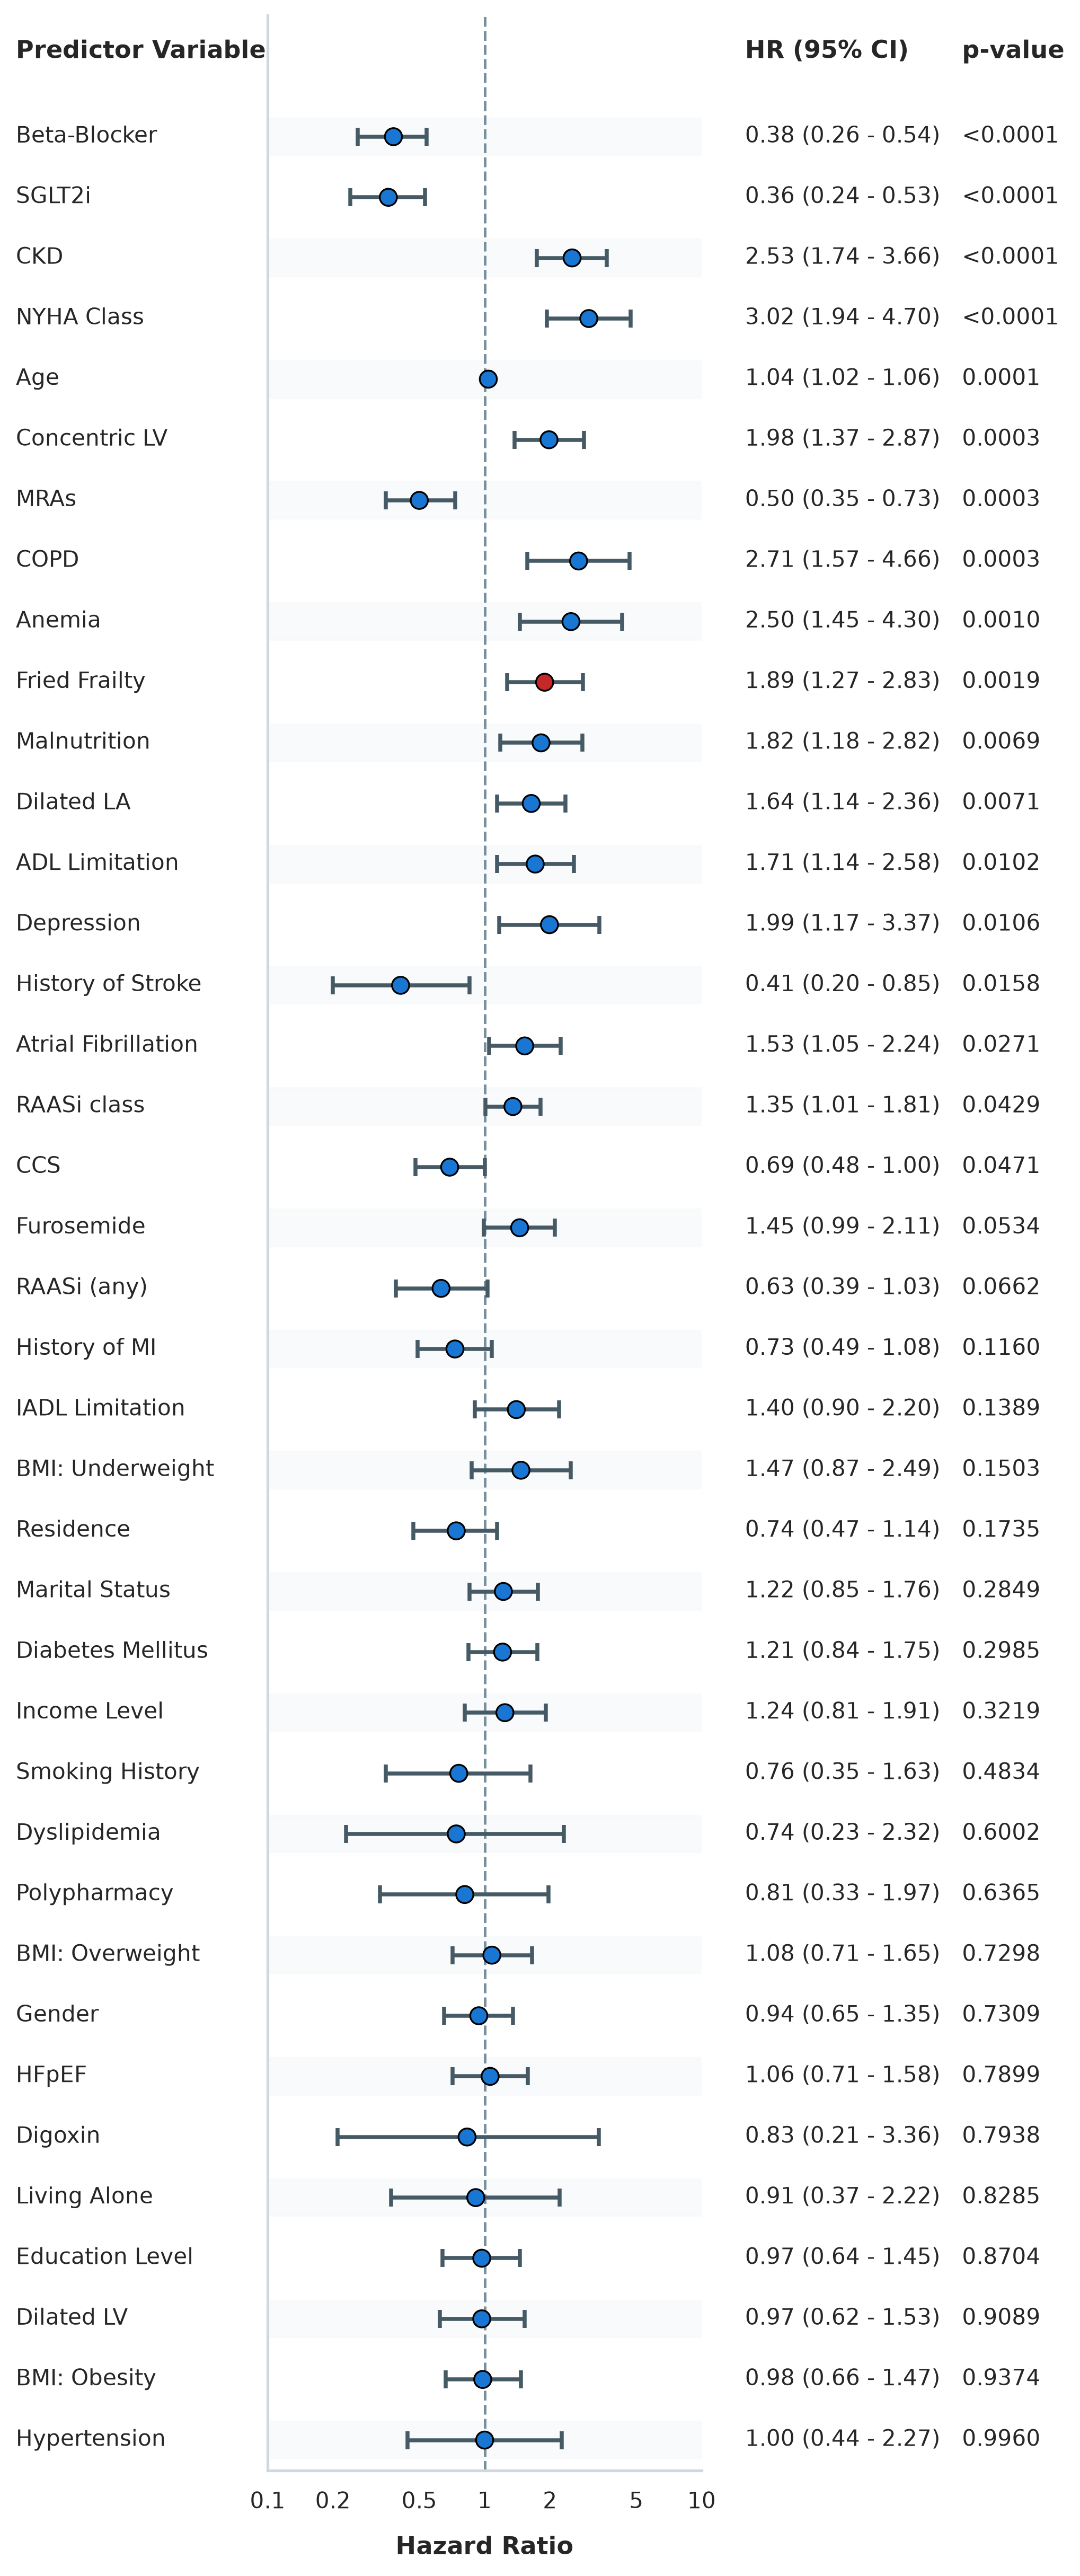

In [147]:
# Screening for All-Cause Hospitalization

all_screening_table, all_multivariable_pool = univariate_cox_screening(
    df=df, 
    time_col='Time_All_hospitalization', 
    event_col='Event_All_Hospitalization', 
    candidate_variables=candidate_confounders, 
    p_threshold=0.20,             # Keep variables with p < 0.2
)

draw_forest_plot(all_screening_table, title = "", save_path="Supplementary Figure S1. Forest plot of univariable Cox proportional hazards analyses for first all-cause rehospitalisation within 6 months.")

### 3.3 Variables selection

In [148]:
', '.join(sorted(filtered_variables))

'AF, Anemia, BB, BMIgroup_1.0, BMIgroup_2.0, BMIgroup_3.0, CCS, CKD, COPD, Concentric_LV, Depression, Dilated_LA, Dilated_LV, Fried_frailty_2, Furosemide, HF_phenotype, Limitation_ADL, Limitation_IADL, MRA, Malnutrition, NYHA, RAASi_B, SGLT2i, diabetes, education, gender, historyMI, income, maritalstatus, residence'

In [149]:
', '.join(sorted(all_multivariable_pool))

'AF, Anemia, BB, BMIgroup_1.0, CCS, CKD, COPD, Concentric_LV, Depression, Dilated_LA, Fried_frailty_2, Furosemide, Limitation_ADL, Limitation_IADL, MRA, Malnutrition, NYHA, RAASi, RAASi_B, SGLT2i, age, historyMI, historystroke, residence'

In [150]:
selected_variables = [
    'age',            # not in filtered_variables because it is a continuous variable
    'gender',
    'Limitation_IADL',
    'CCS',
    'CKD',
    'RAASi_B',     # ARNI  # ARBs/ACEIs
    'BB',
    'MRA',
    'SGLT2i',
    'Fried_frailty_2'
]

print("Filter step:")
for i in selected_variables:
    if i not in filtered_variables:
        print(i)

print("\nUnivariate step:")
for i in selected_variables:
    if i not in all_multivariable_pool:
        print(i)


Filter step:
age

Univariate step:
gender


### 3.4 Likelihood Ratio Test comparing the model with and without Frailty

In [151]:
def run_lrt_for_frailty(df, time_col, event_col, final_selected_variables, frailty_variable='Fried_frailty_2'):
    """
    Performs Likelihood Ratio Test comparing the model with and without Frailty
    using scipy.stats.chi2 and the model log-likelihoods.
    """
    
    baseline_variables = [v for v in final_selected_variables if v != frailty_variable]
    final_selected_variables = baseline_variables + [frailty_variable]
    
    cph_baseline = CoxPHFitter()
    cph_baseline.fit(df[[time_col, event_col] + baseline_variables], 
                     duration_col=time_col, event_col=event_col)
    
    
    cph_full = CoxPHFitter()
    cph_full.fit(df[[time_col, event_col] + final_selected_variables], 
                 duration_col=time_col, event_col=event_col)
    
    
    ll_baseline = cph_baseline.log_likelihood_
    ll_full = cph_full.log_likelihood_
    lrt_stat = 2 * (ll_full - ll_baseline)
    
    
    df_diff = len(final_selected_variables) - len(baseline_variables)
    
    
    p_value = chi2.sf(lrt_stat, df_diff)
    
    print(f"\n=== Likelihood Ratio Test for {event_col} ===")
    print(f"Baseline Log-Likelihood: {ll_baseline:.4f}")
    print(f"Full Model Log-Likelihood: {ll_full:.4f}")
    print(f"LRT Statistic: {lrt_stat:.4f} (df = {df_diff})")
    print(f"LRT p-value: {p_value:.6f}")
    
    if p_value < 0.05:
        print("Conclusion: Adding Frailty status significantly improves the model fit (p < 0.05).")
    else:
        print("Conclusion: Adding Frailty status does NOT significantly improve the model fit (p >= 0.05).")
        
    return lrt_stat, p_value


In [152]:
lrt_stat_all, p_val_all = run_lrt_for_frailty(
    df=df, 
    time_col='Time_All_hospitalization', 
    event_col='Event_All_Hospitalization',
    final_selected_variables=selected_variables
)


=== Likelihood Ratio Test for Event_All_Hospitalization ===
Baseline Log-Likelihood: -619.2737
Full Model Log-Likelihood: -616.4220
LRT Statistic: 5.7033 (df = 1)
LRT p-value: 0.016933
Conclusion: Adding Frailty status significantly improves the model fit (p < 0.05).


### 3.5 C-Index for final models

In [153]:
time_all, event_all = 'Time_All_hospitalization', 'Event_All_Hospitalization'


print("\n=== Model 1: All-Cause Hospitalization (Without Frailty) ===")

cph_1 = CoxPHFitter()
cph_1.fit(
    df[[time_all, event_all] + [c for c in selected_variables if c != "Fried_frailty_2"]
], 
    duration_col=time_all, 
    event_col=event_all
)

apparent_c_index_1 = cph_1.concordance_index_
print(f"Model 1 (Without Frailty) - Apparent C-index:  {apparent_c_index_1:.4f}")
print("-" * 50)



print("=== Model 2: All-Cause Hospitalization (With Frailty) ===")

cph_2 = CoxPHFitter()
cph_2.fit(
    df[[time_all, event_all] + selected_variables], 
    duration_col=time_all, 
    event_col=event_all
)

apparent_c_index_2 = cph_2.concordance_index_
print(f"Model 2 (With Frailty) - Apparent C-index:  {apparent_c_index_2:.4f}")
print("-" * 50)



=== Model 1: All-Cause Hospitalization (Without Frailty) ===
Model 1 (Without Frailty) - Apparent C-index:  0.7172
--------------------------------------------------
=== Model 2: All-Cause Hospitalization (With Frailty) ===
Model 2 (With Frailty) - Apparent C-index:  0.7229
--------------------------------------------------


In [154]:
cph_1.print_summary()

<lifelines.CoxPHFitter: fitted with 313 total observations, 195 right-censored observations>
             duration col = 'Time_All_hospitalization'
                event col = 'Event_All_Hospitalization'
      baseline estimation = breslow
   number of observations = 313
number of events observed = 118
   partial log-likelihood = -619.27
         time fit was run = 2026-07-17 08:22:58 UTC

---
                 coef exp(coef)  se(coef)  coef lower 95%  coef upper 95% exp(coef) lower 95% exp(coef) upper 95%
covariate                                                                                                        
age              0.02      1.02      0.01           -0.00            0.04                1.00                1.05
gender          -0.19      0.83      0.20           -0.57            0.19                0.56                1.21
Limitation_IADL  0.13      1.14      0.27           -0.41            0.67                0.67                1.95
CCS             -0.13      0.88      0.20           -0.51            0.26                0.60                1.29
CKD              0.62      1.86      0.21            0.21            1.03                1.24                2.80
RAASi_B         -0.15      0.86      0.26           -0.67            0.36                0.51                1.43
BB              -0.73      0.48      0.20           -1.11           -0.34                0.33                0.71
MRA             -0.15      0.86      0.21           -0.56            0.25                0.57                1.29
SGLT2i          -0.73      0.48      0.22           -1.16           -0.30                0.31                0.74

                 cmp to     z      p  -log2(p)
covariate                                     
age                0.00  1.61   0.11      3.22
gender             0.00 -0.98   0.33      1.61
Limitation_IADL    0.00  0.48   0.63      0.66
CCS                0.00 -0.65   0.52      0.95
CKD                0.00  2.98 <0.005      8.45
RAASi_B            0.00 -0.59   0.56      0.84
BB                 0.00 -3.67 <0.005     12.00
MRA                0.00 -0.73   0.46      1.11
SGLT2i             0.00 -3.33 <0.005     10.17
---
Concordance = 0.72
Partial AIC = 1256.55
log-likelihood ratio test = 66.58 on 9 df
-log2(p) of ll-ratio test = 33.71

In [155]:
cph_1.summary.loc[:, 'p']

covariate
age                0.107441
gender             0.327411
Limitation_IADL    0.632752
CCS                0.518048
CKD                0.002854
RAASi_B            0.557963
BB                 0.000244
MRA                0.464288
SGLT2i             0.000866
Name: p, dtype: float64

In [156]:
cph_2.print_summary()

<lifelines.CoxPHFitter: fitted with 313 total observations, 195 right-censored observations>
             duration col = 'Time_All_hospitalization'
                event col = 'Event_All_Hospitalization'
      baseline estimation = breslow
   number of observations = 313
number of events observed = 118
   partial log-likelihood = -616.42
         time fit was run = 2026-07-17 08:22:58 UTC

---
                 coef exp(coef)  se(coef)  coef lower 95%  coef upper 95% exp(coef) lower 95% exp(coef) upper 95%
covariate                                                                                                        
age              0.01      1.01      0.01           -0.01            0.04                0.99                1.04
gender          -0.22      0.80      0.20           -0.61            0.16                0.55                1.18
Limitation_IADL -0.16      0.85      0.30           -0.75            0.43                0.47                1.54
CCS             -0.17      0.84      0.19           -0.56            0.21                0.57                1.23
CKD              0.63      1.88      0.21            0.22            1.04                1.24                2.84
RAASi_B         -0.07      0.93      0.26           -0.59            0.45                0.55                1.56
BB              -0.72      0.49      0.20           -1.10           -0.33                0.33                0.72
MRA             -0.15      0.86      0.21           -0.56            0.26                0.57                1.29
SGLT2i          -0.75      0.47      0.22           -1.19           -0.32                0.31                0.73
Fried_frailty_2  0.59      1.80      0.25            0.09            1.08                1.09                2.95

                 cmp to     z      p  -log2(p)
covariate                                     
age                0.00  1.17   0.24      2.05
gender             0.00 -1.13   0.26      1.94
Limitation_IADL    0.00 -0.53   0.60      0.75
CCS                0.00 -0.90   0.37      1.43
CKD                0.00  3.00 <0.005      8.51
RAASi_B            0.00 -0.27   0.79      0.35
BB                 0.00 -3.62 <0.005     11.73
MRA                0.00 -0.72   0.47      1.09
SGLT2i             0.00 -3.42 <0.005     10.63
Fried_frailty_2    0.00  2.31   0.02      5.57
---
Concordance = 0.72
Partial AIC = 1252.84
log-likelihood ratio test = 72.28 on 10 df
-log2(p) of ll-ratio test = 35.86

In [157]:
cph_2.summary.loc[:, 'p']

covariate
age                0.241788
gender             0.260095
Limitation_IADL    0.596366
CCS                0.370381
CKD                0.002737
RAASi_B            0.785996
BB                 0.000294
MRA                0.469420
SGLT2i             0.000631
Fried_frailty_2    0.021075
Name: p, dtype: float64

In [158]:
def bootstrap_c_index_ci(df, duration_col, event_col, covariates, n_bootstraps=1000, seed=42):
    """
    Calculate Harrell's C-statistic and 95% CI via bootstrap resampling.
    
    IMPORTANT: reset_index(drop=True) is required to avoid a duplicate-index 
    bug in lifelines where concordance_index_ returns wrong values.
    """
    rng = np.random.default_rng(seed)
    cols = [duration_col, event_col] + covariates
    clean_df = df[cols].dropna().reset_index(drop=True)
    n = len(clean_df)
    
    boot_c_indices = []
    for _ in range(n_bootstraps):
        boot_df = clean_df.sample(n=n, replace=True, random_state=int(rng.integers(0, 1_000_000)))
        boot_df = boot_df.reset_index(drop=True)  # Critical fix!
        try:
            boot_cph = CoxPHFitter()
            boot_cph.fit(boot_df, duration_col=duration_col, event_col=event_col, show_progress=False)
            boot_c_indices.append(boot_cph.concordance_index_)
        except Exception:
            continue
    
    c_mean   = np.mean(boot_c_indices)
    ci_lower = np.percentile(boot_c_indices, 2.5)
    ci_upper = np.percentile(boot_c_indices, 97.5)
    return c_mean, ci_lower, ci_upper


# --- Model 1: Without Frailty ---
vars_no_frailty = [c for c in selected_variables if c != "Fried_frailty_2"]
c1_boot, lo1, hi1 = bootstrap_c_index_ci(
    df, time_all, event_all, vars_no_frailty
)
print(f"Model 1 (Without Frailty) - C-statistic: {apparent_c_index_1:.3f} (95% CI: {lo1:.3f}–{hi1:.3f})")

# --- Model 2: With Frailty ---
c2_boot, lo2, hi2 = bootstrap_c_index_ci(
    df, time_all, event_all, selected_variables
)
print(f"Model 2 (With Frailty)    - C-statistic: {apparent_c_index_2:.3f} (95% CI: {lo2:.3f}–{hi2:.3f})")


Model 1 (Without Frailty) - C-statistic: 0.717 (95% CI: 0.685–0.771)
Model 2 (With Frailty)    - C-statistic: 0.723 (95% CI: 0.692–0.777)


### 3.6 Final model

In [159]:
cph_2.print_summary()

<lifelines.CoxPHFitter: fitted with 313 total observations, 195 right-censored observations>
             duration col = 'Time_All_hospitalization'
                event col = 'Event_All_Hospitalization'
      baseline estimation = breslow
   number of observations = 313
number of events observed = 118
   partial log-likelihood = -616.42
         time fit was run = 2026-07-17 08:22:58 UTC

---
                 coef exp(coef)  se(coef)  coef lower 95%  coef upper 95% exp(coef) lower 95% exp(coef) upper 95%
covariate                                                                                                        
age              0.01      1.01      0.01           -0.01            0.04                0.99                1.04
gender          -0.22      0.80      0.20           -0.61            0.16                0.55                1.18
Limitation_IADL -0.16      0.85      0.30           -0.75            0.43                0.47                1.54
CCS             -0.17      0.84      0.19           -0.56            0.21                0.57                1.23
CKD              0.63      1.88      0.21            0.22            1.04                1.24                2.84
RAASi_B         -0.07      0.93      0.26           -0.59            0.45                0.55                1.56
BB              -0.72      0.49      0.20           -1.10           -0.33                0.33                0.72
MRA             -0.15      0.86      0.21           -0.56            0.26                0.57                1.29
SGLT2i          -0.75      0.47      0.22           -1.19           -0.32                0.31                0.73
Fried_frailty_2  0.59      1.80      0.25            0.09            1.08                1.09                2.95

                 cmp to     z      p  -log2(p)
covariate                                     
age                0.00  1.17   0.24      2.05
gender             0.00 -1.13   0.26      1.94
Limitation_IADL    0.00 -0.53   0.60      0.75
CCS                0.00 -0.90   0.37      1.43
CKD                0.00  3.00 <0.005      8.51
RAASi_B            0.00 -0.27   0.79      0.35
BB                 0.00 -3.62 <0.005     11.73
MRA                0.00 -0.72   0.47      1.09
SGLT2i             0.00 -3.42 <0.005     10.63
Fried_frailty_2    0.00  2.31   0.02      5.57
---
Concordance = 0.72
Partial AIC = 1252.84
log-likelihood ratio test = 72.28 on 10 df
-log2(p) of ll-ratio test = 35.86

### 3.7 Proportional Hazards (PH) Assumption Testing

In [160]:
def check_ph_assumptions(model, df_subset, title_suffix="", filename = "schoenfeld_residual"):
    
    # 1. Run the Grambsch-Therneau test with identity, rank, and km transformations
    test_results = proportional_hazard_test(model, df_subset, time_transform=['identity', 'rank', 'km'])
    individual_df = test_results.summary.copy()
    
    # Calculate the global/whole model test statistic for each transformation
    event_observed, durations, weights = model.event_observed, model.durations, model.weights
    n_deaths = event_observed.sum()
    scaled_resids = model.compute_residuals(df_subset, kind="scaled_schoenfeld")
    cov_matrix = model.variance_matrix_.values
    inv_cov_matrix = np.linalg.inv(cov_matrix)
    df = len(model.params_)
    
    global_rows = []
    for transform_name in ['identity', 'rank', 'km']:
        transformer = TimeTransformers().get(transform_name)
        times = transformer(durations, event_observed, weights)[event_observed.values]
        demeaned_times = times - times.mean()
        
        # G vector: sum over deaths of demeaned_time * residual
        G = (demeaned_times.values[:, None] * scaled_resids.values).sum(0)
        
        # Var(G) factor: n_deaths * sum(demeaned_time^2)
        var_factor = n_deaths * (demeaned_times**2).sum()
        
        # T_global = G^T * inv(cov_matrix) * G / var_factor
        T_global = G.T @ inv_cov_matrix @ G / var_factor
        
        # p-value from chi-square distribution with df degrees of freedom
        p_val = 1 - chi2.cdf(T_global, df)
        neg_log2_p = -np.log2(p_val) if p_val > 0 else np.nan
        
        global_rows.append({
            'covariate': 'GLOBAL',
            'transform': transform_name,
            'test_statistic': T_global,
            'p': p_val,
            '-log2(p)': neg_log2_p
        })
        
    global_df = pd.DataFrame(global_rows).set_index(['covariate', 'transform'])
    global_df.index.names = individual_df.index.names
    
    # Merge individual and global summaries
    merged_summary = pd.concat([individual_df, global_df])
    
    print(f"=== Proportional Hazard Test (All Transforms) - {title_suffix} (Including Global) ===")
    print(merged_summary.to_string(formatters={
        'test_statistic': '{:.6f}'.format,
        'p': '{:.6f}'.format,
        '-log2(p)': '{:.6f}'.format
    }))
    
    # Compute the quadratic form of the scaled Schoenfeld residuals for each subject
    global_resids = (scaled_resids.values @ inv_cov_matrix * scaled_resids.values).sum(axis=1)
    
    # Combined plot: (n_covs + 1) rows, 3 columns
    covariates = list(scaled_resids.columns)
    n_covs = len(covariates)
    n_rows = n_covs + 1
    n_cols = 3
    
    fig, axes = plt.subplots(n_rows, n_cols, figsize=(15, 3.5 * n_rows), dpi=300)
    
    try:
        from statsmodels.api import nonparametric
        lowess = nonparametric.lowess
    except ImportError:
        lowess = None
        
    np.random.seed(42)
    transformers = dict(TimeTransformers().iter(['identity', 'rank', 'km']))
    
    # 2. Plot individual covariates
    for row_idx, cov in enumerate(covariates):
        y = scaled_resids[cov]
        
        for col_idx, transform_name in enumerate(['identity', 'rank', 'km']):
            ax = axes[row_idx, col_idx]
            transformer = transformers[transform_name]
            tt = transformer(durations, event_observed, weights)[event_observed.values]
            
            # Scatter plot of residuals (Sky Blue)
            ax.scatter(tt, y, color='#3498db', alpha=0.7, s=15, edgecolors='none')
            ax.axhline(0, color='black', linestyle='--', linewidth=1.0)
            
            n_pts = len(tt)
            # Bootstrap lowess curves (15 iterations)
            for _ in range(15):
                ix = sorted(np.random.choice(n_pts, n_pts))
                tt_boot = tt.values[ix] if hasattr(tt, 'values') else tt[ix]
                y_boot = y.values[ix]
                if lowess is not None:
                    try:
                        smoothed_boot = lowess(y_boot, tt_boot, frac=0.6)
                        ax.plot(smoothed_boot[:, 0], smoothed_boot[:, 1], color='gray', alpha=0.25, linewidth=1.0)
                    except Exception:
                        pass
                else:
                    z = np.polyfit(tt_boot, y_boot, 1)
                    p = np.poly1d(z)
                    ax.plot(tt_boot, p(tt_boot), color='gray', alpha=0.25, linewidth=1.0)
                    
            # Main lowess line
            if lowess is not None:
                smoothed = lowess(y, tt, frac=0.6)
                ax.plot(smoothed[:, 0], smoothed[:, 1], color='black', linewidth=2.0)
            else:
                z = np.polyfit(tt, y, 1)
                p = np.poly1d(z)
                ax.plot(tt, p(tt), color='black', linewidth=2.0)
                
            ax.set_title(f"{cov} ({transform_name.capitalize()})", fontsize=10, fontweight='bold')
            ax.set_xlabel(f"{transform_name}-transformed time", fontsize=8)
            ax.set_ylabel("Scaled Residual", fontsize=8)
            ax.grid(False)
            
    # 3. Plot GLOBAL residuals in the last row
    global_row_idx = n_covs
    for col_idx, transform_name in enumerate(['identity', 'rank', 'km']):
        ax = axes[global_row_idx, col_idx]
        transformer = transformers[transform_name]
        tt = transformer(durations, event_observed, weights)[event_observed.values]
        
        # Scatter plot of global residuals (Soft Coral Red)
        ax.scatter(tt, global_resids, color='#e74c3c', alpha=0.7, s=15, edgecolors='none')
        
        # Expected value reference line under null (df)
        ax.axhline(df, color='black', linestyle='--', linewidth=1.0)
        
        n_pts = len(tt)
        # Bootstrap lowess curves (15 iterations)
        for _ in range(15):
            ix = sorted(np.random.choice(n_pts, n_pts))
            tt_boot = tt.values[ix] if hasattr(tt, 'values') else tt[ix]
            y_boot = global_resids[ix]
            if lowess is not None:
                try:
                    smoothed_boot = lowess(y_boot, tt_boot, frac=0.6)
                    ax.plot(smoothed_boot[:, 0], smoothed_boot[:, 1], color='gray', alpha=0.25, linewidth=1.0)
                except Exception:
                    pass
            else:
                z = np.polyfit(tt_boot, y_boot, 1)
                p = np.poly1d(z)
                ax.plot(tt_boot, p(tt_boot), color='gray', alpha=0.25, linewidth=1.0)
                
        # Main lowess line
        if lowess is not None:
            smoothed = lowess(global_resids, tt, frac=0.6)
            ax.plot(smoothed[:, 0], smoothed[:, 1], color='black', linewidth=2.0)
        else:
            z = np.polyfit(tt, global_resids, 1)
            p = np.poly1d(z)
            ax.plot(tt, p(tt), color='black', linewidth=2.0)
            
        ax.set_title(f"GLOBAL ({transform_name.capitalize()})", fontsize=10, fontweight='bold', color='#c0392b')
        ax.set_xlabel(f"{transform_name}-transformed time", fontsize=8)
        ax.set_ylabel("Global Quadratic Resid", fontsize=8)
        ax.grid(False)
            
    fig.suptitle(f"Schoenfeld Residuals - {title_suffix}", fontsize=14, fontweight='bold', y=0.99)
    plt.tight_layout(rect=[0, 0, 1, 0.98])
    
    # Save the plot with specific filenames filename
    plt.savefig(filename, dpi=300, bbox_inches='tight')
    plt.show()


In [161]:
final_all_data = df[['Time_All_hospitalization', 'Event_All_Hospitalization'] + selected_variables]
check_ph_assumptions(cph_2, final_all_data, title_suffix="All-Cause Hospitalization", filename = "Supplementary Figure S3. Scaled Schoenfeld residual plots for covariates included in Model 2.png")

=== Proportional Hazard Test (All Transforms) - All-Cause Hospitalization (Including Global) ===
                         test_statistic        p -log2(p)
BB              identity       1.359494 0.243625 2.037265
                km             2.442760 0.118068 3.082307
                rank           2.466634 0.116287 3.104241
CCS             identity       0.001706 0.967056 0.048329
                km             0.012882 0.909634 0.136641
                rank           0.013243 0.908382 0.138628
CKD             identity       0.056440 0.812214 0.300068
                km             0.327812 0.566950 0.818706
                rank           0.278953 0.597388 0.743259
Fried_frailty_2 identity       0.771598 0.379723 1.396980
                km             0.565017 0.452246 1.144821
                rank           0.624843 0.429253 1.220099
Limitation_IADL identity       3.246946 0.071557 3.804770
                km             3.727068 0.053537 4.223312
                rank           3.

### 3.8 Proportional Hazards (PH) Assumption Testing Log-Minus-Log

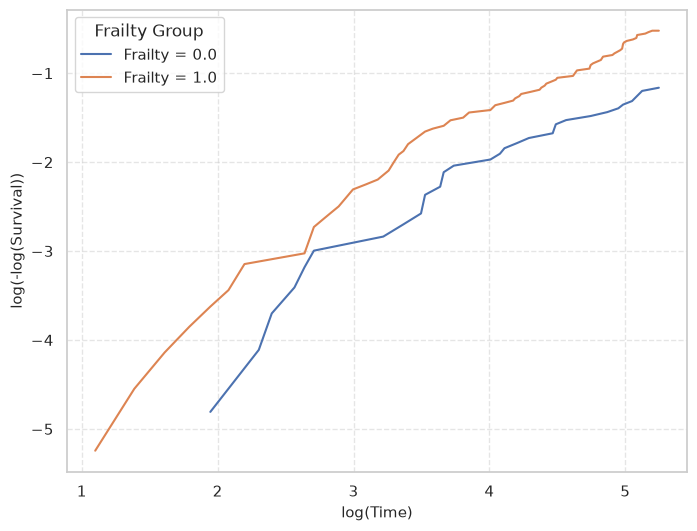

In [162]:
plt.figure(figsize=(8, 6))

for group, group_df in df.groupby('Fried_frailty_2'):
    kmf = KaplanMeierFitter().fit(
        group_df['Time_All_hospitalization'], 
        group_df['Event_All_Hospitalization']
    )
    
    # Filter out invalid time=0 or survival=1.0 values to avoid log of 0/infinity errors
    survival = kmf.survival_function_
    valid = survival[(survival.index > 0) & (survival.iloc[:, 0] < 1.0)]
    
    # LML transformation
    lml = np.log(-np.log(valid.iloc[:, 0]))
    plt.plot(np.log(valid.index), lml.values, label=f"Frailty = {group}")

# Title and labels
plt.title("", fontsize=12, fontweight='bold', pad=15)
plt.xlabel("log(Time)", fontsize=11)
plt.ylabel("log(-log(Survival))", fontsize=11)
plt.legend(title="Frailty Group")
plt.grid(True, linestyle='--', alpha=0.5)
plt.savefig("Supplementary Figure S2. Log-minus-log survival plot for first all-cause rehospitalisation by frailty status.png", dpi=300, bbox_inches='tight')
plt.show()
